# 19. TARP_Final_Project_Summary_Notebook

## Project Title: Traffic Accident Risk Prediction (TARP)

**Unit:** SIT782  
**Prepared by:** Khalid Ameen  

**Project Team:**  
- Suba (225094537)  
- Burhan (224802775)  
- Khalid (224696667)  


**Objective**

This notebook provides a **client-friendly dashboard summary** for the Traffic Accident Risk Prediction project.

It is designed to sit near the end of the project workflow, after the crash, weather, mobility, feature engineering, integration, and modelling notebooks have been completed.

The purpose of this notebook is to present the most important project outcomes in one place using:

- KPI summary cards
- severity distribution charts
- crash trend charts
- speed zone and severity visuals
- weather insights
- mobility insights
- model comparison chart
- class-wise fatal accident performance
- feature importance chart
- final model summary


## 1. Project Overview

The **Traffic Accident Risk Prediction (TARP)** project aims to analyse historical road crash data together with weather and mobility-related data to identify accident risk patterns.

For a non-technical local government audience, this dashboard helps answer questions such as:

- When are crashes more likely to occur?
- Which severity categories are most common?
- Are certain speed zones associated with more severe crashes?
- Do weather conditions show any relationship with crash frequency or severity?
- Which features are most useful for predicting crash risk?
- Which model performs best for the final prediction task?

The goal is not only to build a model, but to support better road safety planning and evidence-based decision-making.


In [8]:
# 1. Setting up and importing libraries

import os
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load Final Integrated Dataset

In [ ]:
# 2. Loading Dataset

# We start off by uploading the earlier finalized data for this notebook

DATA_PATH = Path("../../../datascience/usecases/DEPENDENCIES/"
    "UC00227_Traffic_Accident_Risk_Prediction/"
    "data/final/updated_final_model_dataset.csv")

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded from: {DATA_PATH}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

display(df.head())

Dataset loaded from: D:\Git\SIT782\TARP01\MOP-Code\Playground\KhalidT12026\Traffic_Accident_Prediction\data\final\updated_final_model_dataset.csv
Rows: 151,951
Columns: 107


,ACCIDENT_NO,date,ACCIDENT_TIME,ACCIDENT_TYPE,DCA_CODE,DCA_CODE_DESCRIPTION,LIGHT_CONDITION,POLICE_ATTEND,ROAD_GEOMETRY,SEVERITY,SPEED_ZONE,RUN_OFFROAD,ROAD_NAME,ROAD_TYPE,ROAD_ROUTE_1,LGA_NAME,DTP_REGION,LATITUDE,LONGITUDE,VICGRID_X,VICGRID_Y,TOTAL_PERSONS,INJ_OR_FATAL,FATALITY,SERIOUSINJURY,OTHERINJURY,NONINJURED,MALES,FEMALES,BICYCLIST,PASSENGER,DRIVER,PEDESTRIAN,PILLION,MOTORCYCLIST,UNKNOWN,PED_CYCLIST_5_12,PED_CYCLIST_13_18,OLD_PED_65_AND_OVER,OLD_DRIVER_75_AND_OVER,YOUNG_DRIVER_18_25,NO_OF_VEHICLES,HEAVYVEHICLE,PASSENGERVEHICLE,MOTORCYCLE,PT_VEHICLE,DEG_URBAN_NAME,SRNS,RMA,DIVIDED,...,rush_hour,speed_zone_numeric,time_period,week_part,Min temperature (°C),Max temperature (°C),Total Rainfall (mm),Time of maximum gust,Direction of wind,max wind speed (km/h),max gust speed(km/h),max pressure (hPa),Max Humidity (%),Min Humidity (%),source_file,day,month_y,year_y,month_name,weekday,rain_indicator,temperature_range,humidity_range,gust_to_wind_ratio,is_hot_day,is_heavy_rain_day,wind_dir_Calm,wind_dir_E,wind_dir_ENE,wind_dir_ESE,wind_dir_N,wind_dir_N / NNW,wind_dir_NE,wind_dir_NNE,wind_dir_NNW,wind_dir_NW,wind_dir_NW/NNW,wind_dir_S,wind_dir_S / SSW,wind_dir_S/SSW,wind_dir_SE,wind_dir_SSE,wind_dir_SSW,wind_dir_SW,wind_dir_W,wind_dir_WNW,wind_dir_WSW,wind_dir_WSW / S,pedestrian_density,bicycle_density
0,T20230013207,2023-06-06,1900-01-01 22:14:00,Collision with vehicle,140,U TURN,Dark Street lights on,Yes,Not at intersection,Serious injury accident,50 km/hr,No,CUMBERLAND,ROAD,5749.0,MORELAND,INNER METRO,-37.723442,144.93985,2494697.067,2419717.845,2,2,0,1,1,0,2,0,0,0,2,0,0,0,0,0,0,0,0,0,2.0,0.0,2.0,0.0,0.0,MELB_URBAN,NaN,Arterial Other,Undivided,...,0,50.0,Off-Peak,Weekday,13.5,17.3,0.0,14:00,N,24.0,44.0,1021.5,98.0,70.0,Weather archive 2015-2026,6.0,6.0,2023.0,June,Tuesday,0.0,3.8,28.0,1.833333,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.115603,0.026178
1,T20240014902,2024-04-19,1900-01-01 02:10:00,Collision with vehicle,140,U TURN,Dark Street lights on,Yes,Not at intersection,Other injury accident,40 km/hr,No,CHAPEL,STREET,9999.0,STONNINGTON,INNER METRO,-37.850610,144.99355,2499432.181,2405605.392,3,1,0,0,1,2,2,1,0,1,2,0,0,0,0,0,0,0,0,0,2.0,0.0,2.0,0.0,0.0,MELB_URBAN,NaN,Local Road,Undivided,...,0,40.0,Off-Peak,Weekday,11.1,21.3,3.6,18:26,S,20.0,43.0,1014.2,100.0,39.0,Weather archive 2015-2026,19.0,4.0,2024.0,April,Friday,1.0,10.2,61.0,2.150000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.011888,0.000000
2,T20160009452,2016-04-30,1900-01-01 23:50:00,Collision with vehicle,120,HEAD ON (NOT OVERTAKING),Dark No street lights,Yes,Not at intersection,Serious injury accident,100 km/hr,No,BRANDY CREEK,ROAD,5532.0,BAW BAW,GIPPSLAND,-38.111640,145.92566,2581181.074,2376237.515,3,3,0,1,2,0,1,2,0,1,2,0,0,0,0,0,0,0,0,0,2.0,0.0,2.0,0.0,0.0,RURAL_VICTORIA,C,Arterial Other,Undivided,...,0,100.0,Off-Peak,Weekend,20.3,23.8,0.0,14:50,N,28.0,46.0,1013.7,74.0,56.0,Weather archive 2015-2026,30.0,4.0,2016.0,April,Saturday,0.0,3.5,18.0,1.642857,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.269190,0.005236
3,T20230001223,2023-01-17,1900-01-01 15:56:00,Collision with vehicle,113,RIGHT NEAR (INTERSECTIONS ONLY),Day,Yes,Private property,Serious injury accident,100 km/hr,No,MIDLAND,HIGHWAY,2590.0,SHEPPARTON,HUME,-36.409386,145.25609,2522967.147,2565502.025,4,1,0,1,0,3,0,4,0,2,2,0,0,0,0,0,0,0,0,1,2.0,0.0,2.0,0.0,0.0,RURAL_VICTORIA,A,Arterial Highway,Undivided,...,1,100.0,Evening Peak,Weekday,20.0,37.1,4.0,12:30,N,28.0,39.0,1016.1,96.0,25.0,Weather archive 2015-2026,17.0,1.0,2023.0,January,Tuesday,1.0,17.1,71.0,1.392857,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.615111,0.089005
4,T20220001324,2022-01-21,1900-01-01 22:45:00,Fall from or in moving vehicle,190,FELL IN/FROM VEHICLE,Dark Street lights on,Yes,Cross intersection,Serious injury accident,50

In [12]:
# 3. Adding the helper functions

# Creating combined mobility indicator from pedestrian and bicycle density

mobility_density_cols = ["pedestrian_density", "bicycle_density"]

df["combined_mobility_density"] = df[mobility_density_cols].mean(axis=1)

mobility_col = "combined_mobility_density"

def find_col(possible_names, dataframe=df):
    """Return the first column that matches possible names exactly or partially."""
    cols = list(dataframe.columns)
    lower_map = {c.lower(): c for c in cols}

    for name in possible_names:
        if name.lower() in lower_map:
            return lower_map[name.lower()]

    for name in possible_names:
        name_l = name.lower()
        for c in cols:
            if name_l in c.lower():
                return c

    return None


def safe_value_counts(dataframe, column, top_n=10, normalize=False):
    if column is None or column not in dataframe.columns:
        return pd.Series(dtype=float)

    result = dataframe[column].value_counts(dropna=False, normalize=normalize).head(top_n)
    return result


def plot_bar(series, title, xlabel="", ylabel="Count", rotation=45):
    if series.empty:
        display(Markdown(f"**Chart skipped:** `{title}` could not be created because the required column was not found."))
        return

    plt.figure(figsize=(10, 5))
    series.plot(kind="bar")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    plt.show()


def plot_line(series, title, xlabel="", ylabel="Count"):
    if series.empty:
        display(Markdown(f"**Chart skipped:** `{title}` could not be created because the required date/time column was not found."))
        return

    plt.figure(figsize=(12, 5))
    series.plot(kind="line", marker="o")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


def display_kpi(label, value):
    display(Markdown(f"""<div style="border:1px solid #ddd; border-radius:10px; padding:14px; margin:8px 0; background-color:#f8f9fa;">
    <span style="font-size:15px; color:#555;">{label}</span><br>
    <span style="font-size:28px; font-weight:700;">{value}</span>
</div>"""))


# Try to identify common columns automatically
severity_col = find_col(["severity", "crash_severity", "accident_severity", "SEVERITY"])
date_col = find_col(["date", "crash_date", "accident_date", "datetime", "crash_datetime"])
time_col = find_col(["time", "crash_time", "accident_time", "hour"])
hour_col = find_col(["hour", "crash_hour", "accident_hour"])
speed_col = find_col(["speed_zone", "speed limit", "speed_limit", "speedzone"])
weather_col = find_col(["weather", "weather_condition", "conditions", "precipitation", "rainfall"])
mobility_col = find_col(["mobility", "traffic_volume", "volume", "congestion", "density", "movement"])
target_col = find_col(["target", "risk", "fatal", "is_fatal", "crash_risk", "severity_target"])

identified_columns = pd.DataFrame({
    "Purpose": [
        "Severity", "Date", "Time", "Hour", "Speed zone", 
        "Weather", "Mobility", "Target"
    ],
    "Detected column": [
        severity_col, date_col, time_col, hour_col, speed_col,
        weather_col, mobility_col, target_col
    ]
})

display(identified_columns)

,Purpose,Detected column
0,Severity,SEVERITY
1,Date,date
2,Time,ACCIDENT_TIME
3,Hour,hour
4,Speed zone,SPEED_ZONE
5,Weather,Total Rainfall (mm)
6,Mobility,combined_mobility_density
7,Target,INJ_OR_FATAL


## 3. KPI Summary Cards

This section provides a quick overview of the final integrated dataset.

The KPI cards are designed for the project handover notebook so that readers can immediately understand the size and coverage of the dataset.


In [46]:
# KPI cards

display_kpi("Total records in final dataset", f"{len(df):,}")
display_kpi("Total columns/features", f"{df.shape[1]:,}")

if severity_col:
    display_kpi("Number of severity categories", f"{df[severity_col].nunique(dropna=True):,}")

if date_col:
    date_series = pd.to_datetime(df[date_col], errors="coerce")
    if date_series.notna().any():
        display_kpi("Date range", f"{date_series.min().date()} to {date_series.max().date()}")

missing_pct = df.isna().mean().mean() * 100
display_kpi("Overall missing value percentage", f"{missing_pct:.2f}%")

<div style="border:1px solid #ddd; border-radius:10px; padding:14px; margin:8px 0; background-color:#f8f9fa;">
    <span style="font-size:15px; color:#555;">Total records in final dataset</span><br>
    <span style="font-size:28px; font-weight:700;">151,951</span>
</div>

<div style="border:1px solid #ddd; border-radius:10px; padding:14px; margin:8px 0; background-color:#f8f9fa;">
    <span style="font-size:15px; color:#555;">Total columns/features</span><br>
    <span style="font-size:28px; font-weight:700;">108</span>
</div>

<div style="border:1px solid #ddd; border-radius:10px; padding:14px; margin:8px 0; background-color:#f8f9fa;">
    <span style="font-size:15px; color:#555;">Number of severity categories</span><br>
    <span style="font-size:28px; font-weight:700;">4</span>
</div>

<div style="border:1px solid #ddd; border-radius:10px; padding:14px; margin:8px 0; background-color:#f8f9fa;">
    <span style="font-size:15px; color:#555;">Date range</span><br>
    <span style="font-size:28px; font-weight:700;">2015-01-01 to 2025-07-31</span>
</div>

<div style="border:1px solid #ddd; border-radius:10px; padding:14px; margin:8px 0; background-color:#f8f9fa;">
    <span style="font-size:15px; color:#555;">Overall missing value percentage</span><br>
    <span style="font-size:28px; font-weight:700;">1.13%</span>
</div>

### KPI Summary Observations

The final integrated dataset contains **151,951 records** and **108 columns/features**, which provides a strong data foundation for exploratory analysis, modelling, and dashboard reporting.

The dataset covers a long historical period from **1 January 2015 to 31 July 2025**. This wide date range allows the project to analyse long-term crash patterns, seasonal trends, and changes in accident risk over time.

There are **4 severity categories** in the final dataset, which supports severity-based analysis and comparison across different crash outcomes. This is useful for understanding whether certain conditions are linked with more serious crashes.

The overall missing value percentage is only **1.13%**, which suggests that the final dataset is relatively complete after cleaning and integration. This gives confidence that the dataset is suitable for further analysis and modelling, although any important missing values should still be checked before final model training.

Overall, the KPI summary confirms that the final dataset is large, broad, and sufficiently clean for the dashboard and final handover notebook.

## 4. Severity Distribution

This chart shows the distribution of accident severity categories in the final dataset.

**Why this matters:** severity distribution helps the client understand whether the dataset is dominated by low-severity incidents or whether there are enough serious/fatal cases to support risk modelling.


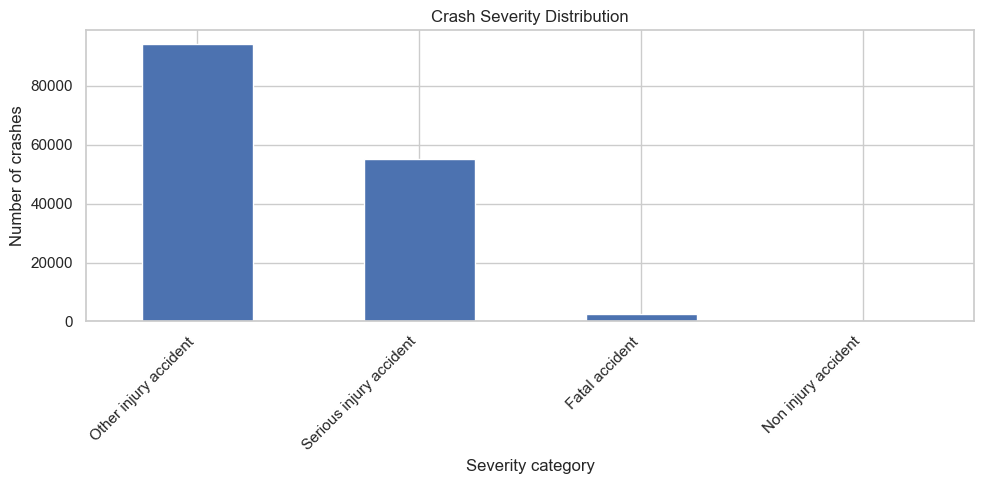

In [21]:
severity_counts = safe_value_counts(df, severity_col, top_n=15)
plot_bar(
    severity_counts,
    title="Crash Severity Distribution",
    xlabel="Severity category",
    ylabel="Number of crashes"
)


### Severity Distribution Observations

The crash severity distribution shows that the dataset is strongly dominated by **Other injury accident**, with **94,133 records**. This is followed by **Serious injury accident**, which also represents a large portion of the dataset.

Fatal accidents appear much less frequently compared with injury-related crashes. This is expected in real-world road safety data, but it also means the dataset is **class imbalanced**.

This imbalance is important for modelling because a model may perform well overall while still struggling to correctly identify rare but critical fatal accident cases. For this reason, model evaluation should not rely on accuracy alone. Metrics such as **recall, precision, F1-score, and class-wise performance** should be reviewed carefully, especially for fatal or high-severity accident prediction.

From a stakeholder perspective, the chart suggests that most recorded crashes involve some level of injury, while fatal crashes are rare but highly important. This supports the need for targeted safety planning focused on reducing both frequent injury crashes and severe/fatal outcomes.

## 5. Crash Trend Over Time

This section shows how crash records change over time.

**Why this matters:** trend analysis helps identify periods with higher crash frequency and supports time-based safety planning.


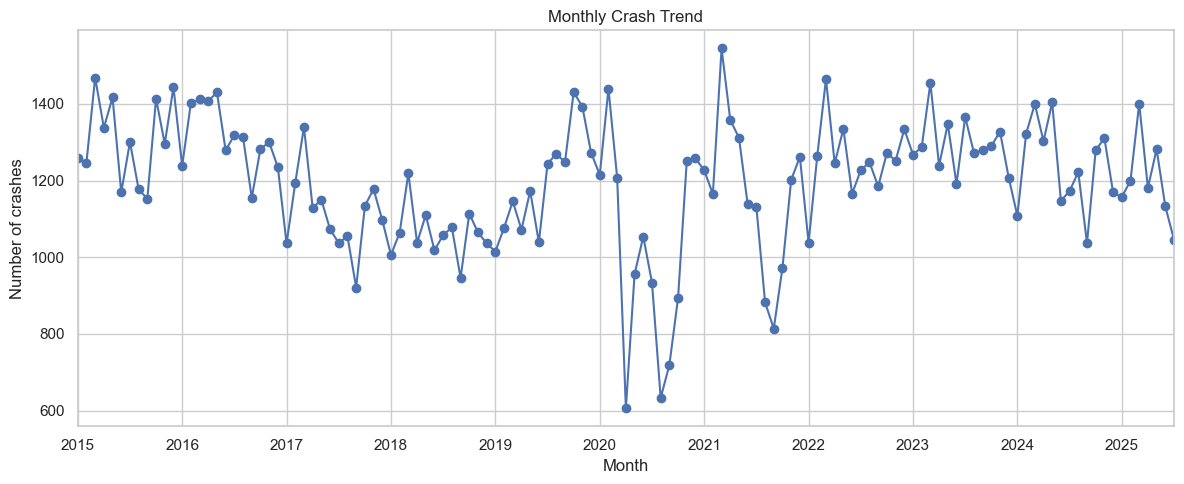

In [22]:
if date_col:
    temp = df.copy()
    temp[date_col] = pd.to_datetime(temp[date_col], errors="coerce")
    temp = temp.dropna(subset=[date_col])

    if len(temp) > 0:
        monthly_trend = temp.set_index(date_col).resample("M").size()
        plot_line(
            monthly_trend,
            title="Monthly Crash Trend",
            xlabel="Month",
            ylabel="Number of crashes"
        )


### Monthly Crash Trend Observations

The monthly crash trend shows that crash volumes fluctuate over time rather than following a completely steady pattern. Across most years, monthly crashes generally remain within a broad range of approximately **1,000 to 1,400 crashes per month**.

A noticeable drop appears around **2020**, where monthly crash counts fall sharply compared with surrounding years. This period should be interpreted carefully, as it may reflect unusual mobility and travel behaviour during COVID-19 restrictions rather than a normal road safety trend.

After 2020, crash volumes appear to recover and return closer to pre-2020 levels, with several months again exceeding **1,300 to 1,400 crashes**. This suggests that changes in travel activity may have had a strong influence on crash frequency.

From a stakeholder perspective, this trend highlights the importance of considering external context such as lockdowns, public holidays, school terms, weather events, and traffic volume when interpreting crash patterns. Crash counts alone should not be treated as risk unless they are compared with mobility or exposure data.

## 6. Crash Pattern by Hour or Time of Day

This section explores whether crashes are concentrated around certain times of the day.

**Why this matters:** local government teams can use time-based risk patterns for targeted signage, enforcement, awareness campaigns, or infrastructure review.


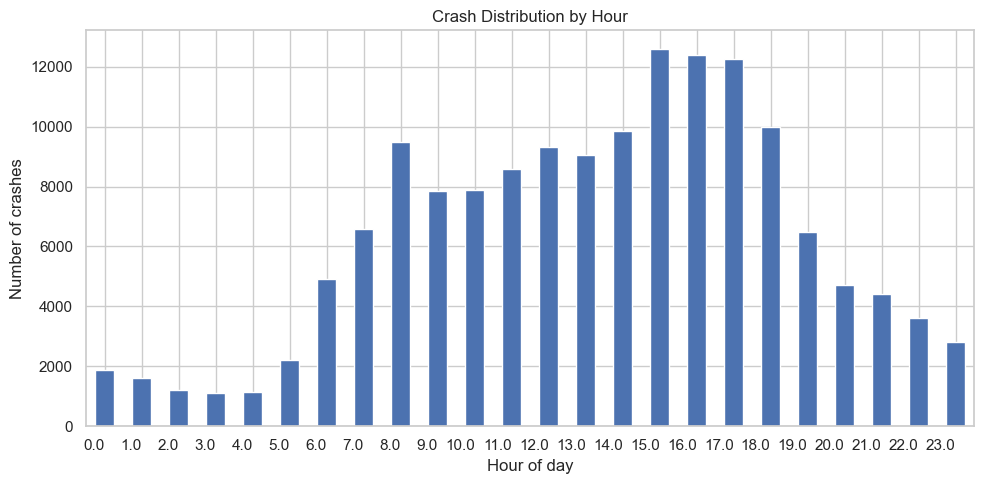

In [23]:
if hour_col:
    hour_counts = df[hour_col].value_counts().sort_index()
    plot_bar(
        hour_counts,
        title="Crash Distribution by Hour",
        xlabel="Hour of day",
        ylabel="Number of crashes",
        rotation=0
    )

elif time_col:
    temp = df.copy()
    parsed_time = pd.to_datetime(temp[time_col], errors="coerce")
    temp["extracted_hour"] = parsed_time.dt.hour
    hour_counts = temp["extracted_hour"].value_counts().sort_index()

    plot_bar(
        hour_counts,
        title="Crash Distribution by Extracted Hour",
        xlabel="Hour of day",
        ylabel="Number of crashes",
        rotation=0
    )
else:
    display(Markdown("**Hourly chart skipped:** no hour or time column was detected."))

### Crash Distribution by Hour Observations

The hourly crash distribution shows a clear increase in crash frequency during daytime and commuting periods. Crash counts are very low during the early morning hours, especially between **1:00 AM and 4:00 AM**, which is expected because traffic activity is generally lower during this period.

Crash numbers begin to rise from around **6:00 AM**, with a noticeable morning peak around **8:00 AM**. This likely reflects increased road activity during the morning commute and school travel period.

The highest crash volumes appear in the afternoon, especially between **3:00 PM and 5:00 PM**, where the number of crashes reaches its strongest levels. This period may be linked to afternoon commuting, school pick-up times, higher pedestrian movement, and general traffic congestion.

After **6:00 PM**, crash counts gradually decrease, suggesting reduced travel activity later in the evening.

From a local government perspective, the afternoon peak period is an important focus area for road safety planning. Potential actions may include reviewing traffic management around schools, busy intersections, pedestrian areas, and high-volume corridors during the afternoon and early evening periods.

## 7. Speed Zone and Severity Visual

This chart summarises crashes by speed zone.

**Why this matters:** speed zones can help identify whether higher-speed environments are associated with increased crash frequency or severity.


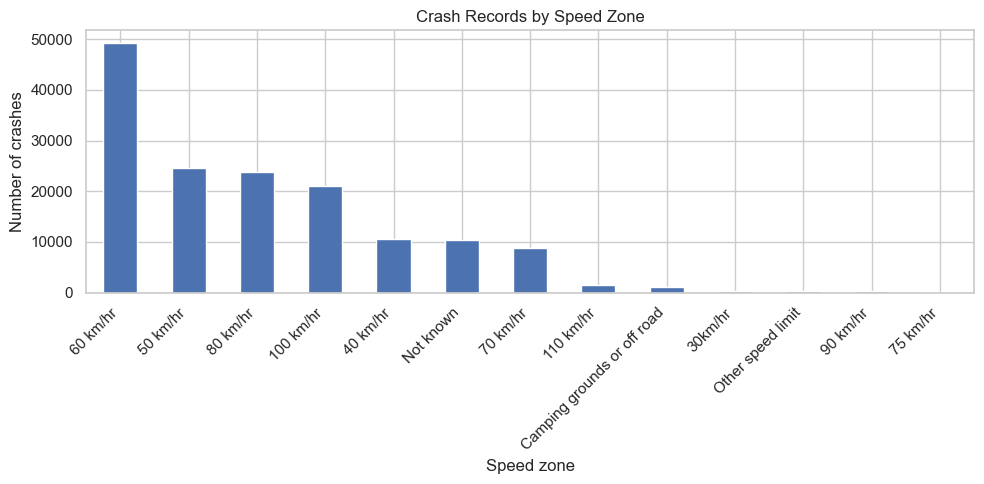

<Figure size 1200x600 with 0 Axes>

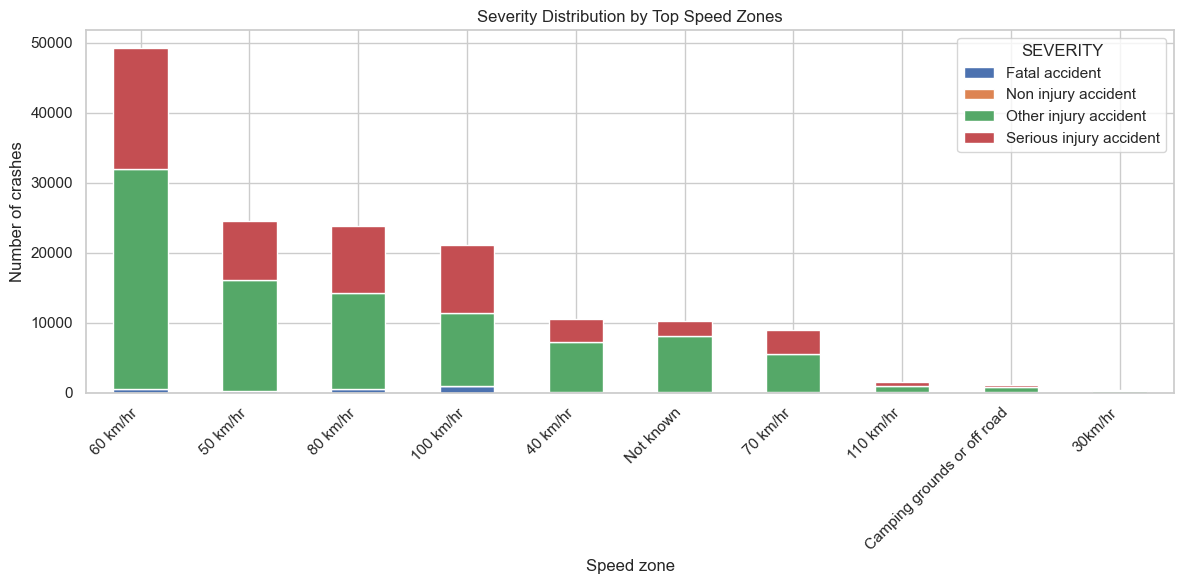

In [47]:
if speed_col:
    speed_counts = safe_value_counts(df, speed_col, top_n=15)
    plot_bar(
        speed_counts,
        title="Crash Records by Speed Zone",
        xlabel="Speed zone",
        ylabel="Number of crashes"
    )

    if severity_col:
        ctab = pd.crosstab(df[speed_col], df[severity_col])
        ctab = ctab.loc[ctab.sum(axis=1).sort_values(ascending=False).head(10).index]

        plt.figure(figsize=(12, 6))
        ctab.plot(kind="bar", stacked=True, figsize=(12, 6))
        plt.title("Severity Distribution by Top Speed Zones")
        plt.xlabel("Speed zone")
        plt.ylabel("Number of crashes")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
else:
    display(Markdown("**Speed zone chart skipped:** no speed zone column was detected."))

### Speed Zone and Severity Observations

The speed zone analysis shows that the largest number of crash records occurred in the **60 km/h** speed zone. This is followed by **50 km/h**, **80 km/h**, and **100 km/h** zones. The high number of crashes in 60 km/h zones may reflect that these roads are common in urban and suburban areas where traffic, intersections, pedestrians, and turning movements are more frequent.

The stacked severity chart shows that **Other injury accident** and **Serious injury accident** make up most crash outcomes across the major speed zones. Fatal accidents are much smaller in number, but they are still present across several speed zones, including higher-speed environments.

The **100 km/h** and **80 km/h** zones appear important from a severity perspective because crashes at higher speeds may have greater injury consequences, even if the total number of crashes is lower than in 60 km/h areas.

The **50 km/h and 60 km/h** zones are also important for local government action because they have high crash volumes and are more likely to include mixed road users such as pedestrians, cyclists, local traffic, schools, shopping areas, and intersections.

From a stakeholder perspective, this suggests two different safety priorities:

1. **High-volume urban zones**, especially 50–60 km/h areas, should be reviewed for intersection safety, pedestrian crossings, cyclist safety, signage, and traffic calming.
2. **Higher-speed zones**, such as 80–100 km/h areas, should be reviewed for severe injury and fatal crash risk, including road design, speed management, visibility, and roadside hazards.

These findings should be interpreted together with traffic exposure, road type, location, and mobility data because a speed zone with more crashes may also simply carry more vehicles.

## 8. Weather Insights

This section summarises weather-related crash patterns.

**Why this matters:** weather conditions can influence road safety by affecting visibility, braking distance, and driver behaviour.


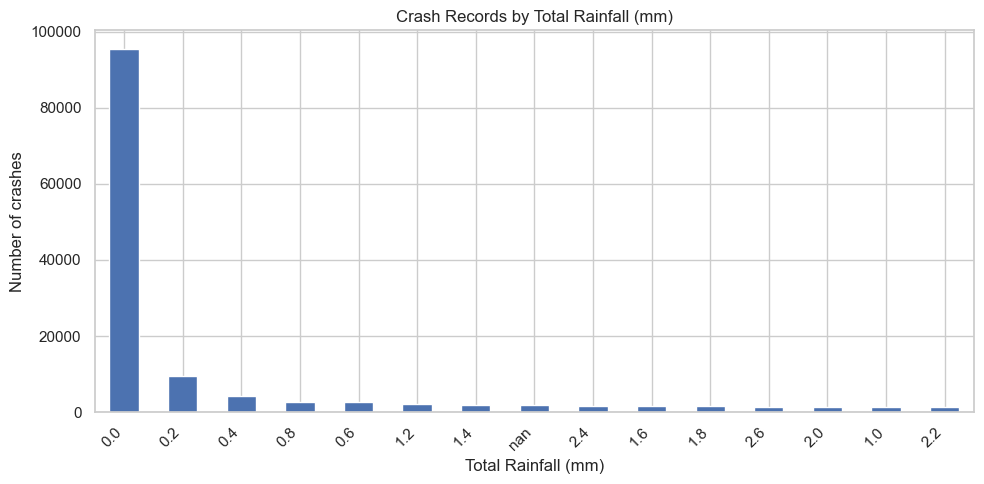

<Figure size 1200x600 with 0 Axes>

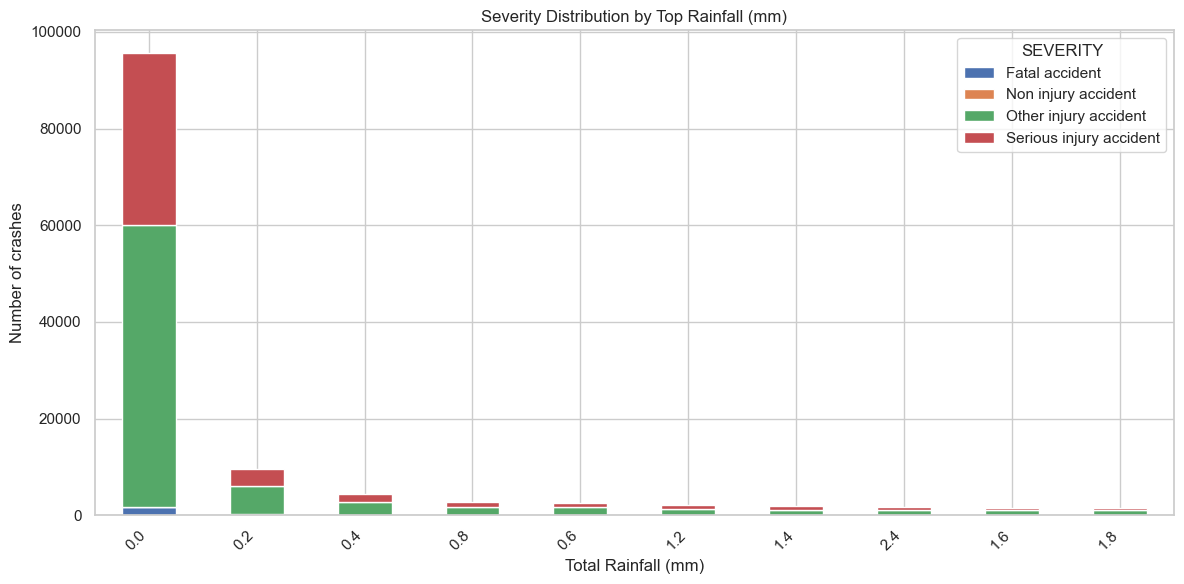

In [26]:
if weather_col:
    weather_counts = safe_value_counts(df, weather_col, top_n=15)
    plot_bar(
        weather_counts,
        title="Crash Records by Total Rainfall (mm)",
        xlabel="Total Rainfall (mm)",
        ylabel="Number of crashes"
    )

    if severity_col:
        weather_severity = pd.crosstab(df[weather_col], df[severity_col])
        weather_severity = weather_severity.loc[weather_severity.sum(axis=1).sort_values(ascending=False).head(10).index]

        plt.figure(figsize=(12, 6))
        weather_severity.plot(kind="bar", stacked=True, figsize=(12, 6))
        plt.title("Severity Distribution by Top Rainfall (mm)")
        plt.xlabel("Total Rainfall (mm)")
        plt.ylabel("Number of crashes")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
else:
    display(Markdown("**Weather insight skipped:** no weather-related column was detected."))

### Rainfall and Crash Severity Observations

The weather-related chart is based on **Total Rainfall (mm)**. Most crash records occurred when rainfall was **0.0 mm**, meaning crashes were most commonly recorded on dry or no-rain days.

This does not necessarily mean dry conditions are more dangerous. It likely reflects that dry/no-rain conditions occur more often than rainy conditions, so there are naturally more crash records during those periods.

Crash records reduce sharply as rainfall increases. Small rainfall values such as **0.2 mm, 0.4 mm, 0.6 mm, and 0.8 mm** still appear in the dataset, but they have much lower crash counts compared with 0.0 mm rainfall.

The severity distribution chart also shows that most crashes across rainfall levels are made up of **Other injury accident** and **Serious injury accident**, while fatal crashes remain much less frequent.

From a stakeholder perspective, this finding should be interpreted carefully. Rainfall may still increase driving risk through reduced visibility, slippery roads, and longer braking distances, but crash counts alone do not prove higher rainfall risk unless compared against how often each rainfall condition occurred and how much traffic was on the road at those times.

For stronger analysis, rainfall should be reviewed together with traffic exposure, time of day, speed zone, and severity rate rather than only total crash count.

## 9. Mobility Insights

This section explores mobility or traffic-volume-related patterns.

**Why this matters:** crash risk should be interpreted alongside mobility exposure. Areas or periods with more movement may naturally have more crash records, so mobility data helps provide better context.


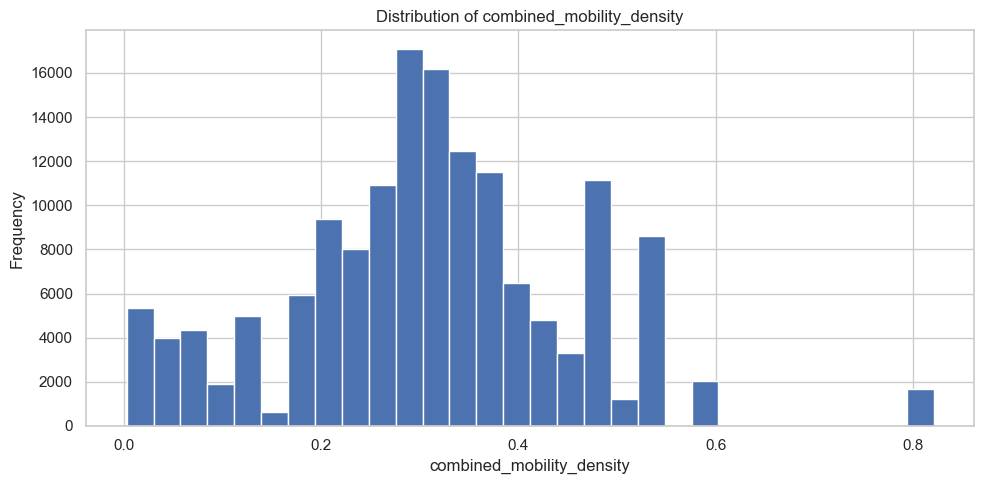

,count,mean,median
SEVERITY,,,
Other injury accident,94133,0.316882,0.311077
Serious injury accident,55277,0.300841,0.298524
Fatal accident,2537,0.270490,0.287298
Non injury accident,4,0.153338,0.151942


In [27]:
if mobility_col:
    if pd.api.types.is_numeric_dtype(df[mobility_col]):
        plt.figure(figsize=(10, 5))
        df[mobility_col].dropna().hist(bins=30)
        plt.title(f"Distribution of {mobility_col}")
        plt.xlabel(mobility_col)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

        if severity_col:
            summary = df.groupby(severity_col)[mobility_col].agg(["count", "mean", "median"]).sort_values("count", ascending=False)
            display(summary)
    else:
        mobility_counts = safe_value_counts(df, mobility_col, top_n=15)
        plot_bar(
            mobility_counts,
            title=f"Crash Records by {mobility_col}",
            xlabel=mobility_col,
            ylabel="Number of crashes"
        )
else:
    display(Markdown("**Mobility insight skipped:** no mobility-related column was detected."))

### Mobility Density Observations

The mobility insight is based on the combined mobility indicator created from **pedestrian_density** and **bicycle_density**. This gives a simple combined measure of active transport movement around crash records.

The distribution of `combined_mobility_density` shows that most crash records are concentrated between approximately **0.20 and 0.50**, with the highest frequency around the **0.25 to 0.35** range. This suggests that many crashes occurred in areas or periods with moderate pedestrian and bicycle activity.

The severity summary table shows that **Other injury accident** has the highest average combined mobility density at approximately **0.317**, followed by **Serious injury accident** at approximately **0.301** and **Fatal accident** at approximately **0.270**.

This suggests that injury crashes are more common where pedestrian and bicycle density is relatively higher. This may reflect busier urban areas, intersections, shopping zones, school areas, or transport corridors where there are more interactions between vehicles and vulnerable road users.

However, this should be interpreted carefully. A higher number of crashes in areas with more pedestrian and bicycle activity does not automatically mean those areas are more dangerous. It may also reflect greater exposure, meaning more people are moving through those areas.

From a local government perspective, this finding supports the need to review road safety around areas with higher pedestrian and bicycle activity. Potential actions may include improving pedestrian crossings, cycling infrastructure, speed management, intersection design, visibility, and separation between vehicles and vulnerable road users.

## 10. Model Comparison Chart

In [ ]:
# Load model comparison results directly from earlier modelling output

model_results_path = Path(
    "../../../datascience/usecases/DEPENDENCIES/"
    "UC00227_Traffic_Accident_Risk_Prediction/"
    "outputs/all_model_comparison.csv"
)

if not model_results_path.exists():
    raise FileNotFoundError(
        f"Model comparison file not found at: {model_results_path}. "
        "Please check the path or move all_model_comparison.csv into the outputs folder."
    )

model_results = pd.read_csv(model_results_path)

Columns found in model comparison file:
['model', 'accuracy', 'precision (macro)', 'recall (macro)', 'f1-score (macro)', 'precision (weighted)', 'recall (weighted)', 'f1-score (weighted)']
Metric columns selected for chart:
['accuracy', 'precision (macro)', 'recall (macro)', 'f1-score (macro)', 'precision (weighted)', 'recall (weighted)', 'f1-score (weighted)']


,model,accuracy,precision (macro),recall (macro),f1-score (macro),precision (weighted),recall (weighted),f1-score (weighted)
0,Logistic Regression,0.451102,0.364228,0.449774,0.314139,0.557436,0.451102,0.484276
1,Decision Tree,0.459526,0.364736,0.442278,0.323380,0.556985,0.459526,0.493191
2,Random Forest,0.518756,0.374305,0.437510,0.357419,0.564031,0.518756,0.533743
3,XGBoost,0.480520,0.366265,0.447649,0.332384,0.557587,0.480520,0.505370


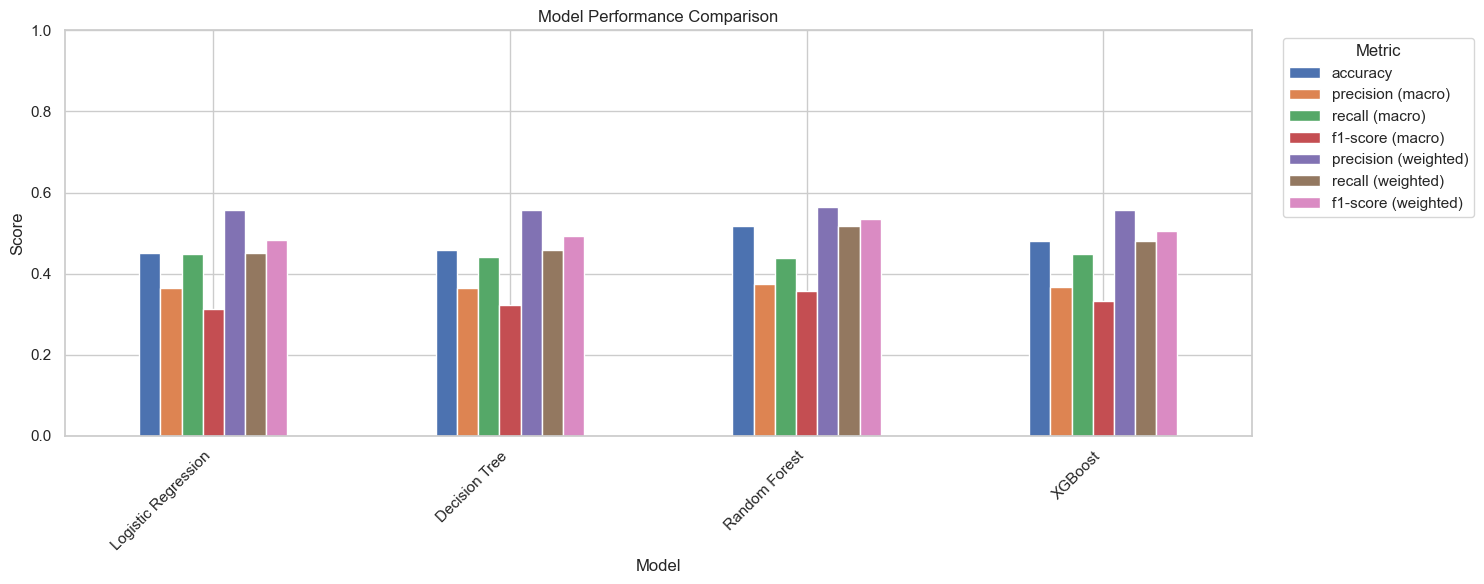

In [37]:
# Clean model comparison table and plot all numeric metrics

model_results_clean = model_results.copy()

# Clean column names
model_results_clean.columns = (
    model_results_clean.columns
    .str.strip()
    .str.lower()
)

print("Columns found in model comparison file:")
print(model_results_clean.columns.tolist())

# Detect model column
model_col = "model"

if model_col not in model_results_clean.columns:
    model_col = model_results_clean.columns[0]
    print(f"'model' column not found. Using first column instead: {model_col}")

# Convert all non-model columns to numeric where possible
for col in model_results_clean.columns:
    if col != model_col:
        model_results_clean[col] = pd.to_numeric(model_results_clean[col], errors="coerce")

# Select all numeric metric columns except model
metric_cols = model_results_clean.select_dtypes(include="number").columns.tolist()

print("Metric columns selected for chart:")
print(metric_cols)

# Display table used for plotting
display(model_results_clean[[model_col] + metric_cols])

# Plot all metrics
plot_df = model_results_clean.set_index(model_col)[metric_cols]

plot_df.plot(kind="bar", figsize=(15, 6))
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Model Performance Comparison Observations

The model comparison chart now compares four models across multiple evaluation metrics: **accuracy, macro precision, macro recall, macro F1-score, weighted precision, weighted recall, and weighted F1-score**.

Based on the results, **Random Forest performs best overall**. It has the highest accuracy at approximately **0.519** and also achieves the strongest **macro F1-score** and **weighted F1-score** among the tested models. This suggests that Random Forest provides the best overall balance across the available models.

**XGBoost** is the second strongest model overall, with performance slightly below Random Forest but generally better than Logistic Regression and Decision Tree on several metrics.

The difference between **macro scores** and **weighted scores** is important. Weighted scores are higher because they give more importance to the majority classes, while macro scores treat all classes equally. Since the crash severity dataset is imbalanced, the lower macro scores suggest that the models are still finding it difficult to predict minority classes such as fatal or rare crash outcomes.

For this reason, the final model should not be selected based on accuracy alone. The project should consider **macro F1-score, recall, and class-wise performance**, especially for serious and fatal crash categories.

Overall, **Random Forest appears to be the most suitable model from the comparison**, but the final recommendation should still review how well it performs on high-severity crash classes.

## 11. Class-wise Crash Severity Model Performance

In [ ]:
# Load class-wise model performance results from outputs folder

outputs_dir = Path(
    "../../../datascience/usecases/DEPENDENCIES/"
    "UC00227_Traffic_Accident_Risk_Prediction/outputs"
)

classwise_results_path = outputs_dir / "advanced_classwise_performance.csv"

if not classwise_results_path.exists():
    raise FileNotFoundError(
        f"Class-wise model performance file not found at: {classwise_results_path}"
    )

classwise_results = pd.read_csv(classwise_results_path)

print(f"Class-wise model performance loaded from: {classwise_results_path}")
display(classwise_results)

Class-wise model performance loaded from: D:\Git\SIT782\TARP01\MOP-Code\Playground\KhalidT12026\Traffic_Accident_Prediction\outputs\advanced_classwise_performance.csv


,Model,Class,Precision,Recall,F1-score,Support
0,Random Forest,Fatal accident,0.044186,0.374753,0.079051,507.0
1,Random Forest,Other injury accident,0.668132,0.670048,0.669089,18827.0
2,Random Forest,Serious injury accident,0.410598,0.267728,0.324117,11056.0
3,XGBoost,Fatal accident,0.038544,0.495069,0.071520,507.0
4,XGBoost,Other injury accident,0.669591,0.640569,0.654759,18827.0
5,XGBoost,Serious injury accident,0.390660,0.207308,0.270874,11056.0


,model,class,precision,recall,f1_score,support
0,Random Forest,Fatal accident,0.044186,0.374753,0.079051,507.0
1,Random Forest,Other injury accident,0.668132,0.670048,0.669089,18827.0
2,Random Forest,Serious injury accident,0.410598,0.267728,0.324117,11056.0
3,XGBoost,Fatal accident,0.038544,0.495069,0.071520,507.0
4,XGBoost,Other injury accident,0.669591,0.640569,0.654759,18827.0


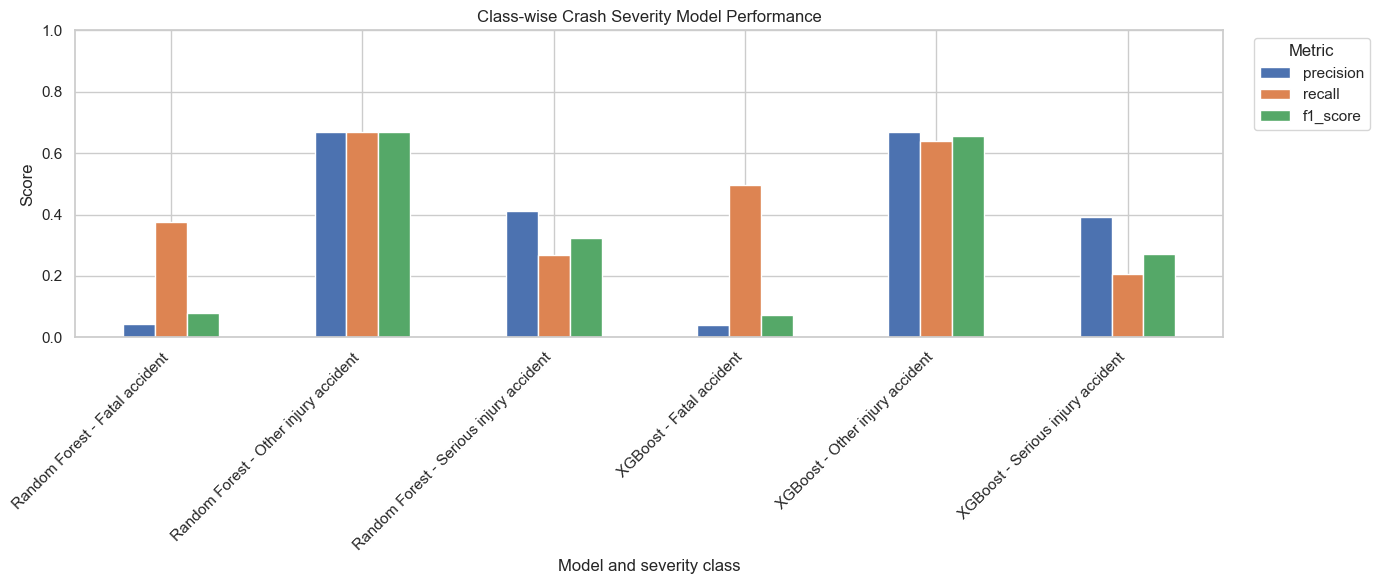

In [40]:
# Clean and plot class-wise model performance

classwise_plot = classwise_results.copy()

classwise_plot.columns = (
    classwise_plot.columns
    .str.strip()
    .str.lower()
    .str.replace("-", "_")
    .str.replace(" ", "_")
)

display(classwise_plot.head())

metrics = ["precision", "recall", "f1_score"]

for col in metrics:
    classwise_plot[col] = pd.to_numeric(classwise_plot[col], errors="coerce")

classwise_plot["model_class"] = (
    classwise_plot["model"].astype(str) + " - " + classwise_plot["class"].astype(str)
)

plot_df = classwise_plot.set_index("model_class")[metrics]

plot_df.plot(kind="bar", figsize=(14, 6))
plt.title("Class-wise Crash Severity Model Performance")
plt.xlabel("Model and severity class")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Class-wise Crash Severity Model Performance Observations

The class-wise model performance chart compares **Random Forest** and **XGBoost** across three crash severity categories: **Fatal accident**, **Other injury accident**, and **Serious injury accident**.

Both models perform best on the **Other injury accident** class. This is expected because this class has the largest number of records in the dataset, giving the models more examples to learn from.

For **Serious injury accident**, Random Forest performs better than XGBoost overall. Random Forest has a stronger F1-score, which means it provides a better balance between precision and recall for this class.

For **Fatal accident**, both models show very low precision and low F1-score. This means the models struggle to identify fatal crashes accurately. XGBoost has higher recall for fatal accidents than Random Forest, meaning it captures more fatal cases, but its very low precision suggests it also produces many false positives.

This result is expected because fatal crashes are rare compared with injury-related crashes. Because of this class imbalance, overall accuracy does not fully explain model performance.

From a road safety perspective, this section is important because fatal and serious injury crashes are the most critical outcomes. The current results suggest that **Random Forest is stronger overall**, but further improvement is needed for predicting rare fatal crash cases before the model could be used for operational decision-making.

## 12. Feature Importance Chart

This section shows which variables were most influential in the final model.

We will load feature importance values saved from the modelling notebook.

In [ ]:
# Load Random Forest feature importance values from outputs folder

outputs_dir = Path(
    "../../../datascience/usecases/DEPENDENCIES/"
    "UC00227_Traffic_Accident_Risk_Prediction/outputs"
)

feature_importance_path = outputs_dir / "random_forest_feature_importance.csv"

if not feature_importance_path.exists():
    raise FileNotFoundError(
        f"Feature importance file not found at: {feature_importance_path}"
    )

feature_importance = pd.read_csv(feature_importance_path)

print(f"Feature importance file loaded from: {feature_importance_path}")
display(feature_importance.head())

Feature importance file loaded from: D:\Git\SIT782\TARP01\MOP-Code\Playground\KhalidT12026\Traffic_Accident_Prediction\outputs\random_forest_feature_importance.csv


,Feature,Importance
0,speed_zone_numeric,0.316591
1,Min temperature (°C),0.108772
2,Max temperature (°C),0.106140
3,pedestrian_density,0.093509
4,Max Humidity (%),0.090413


Columns found:
['feature', 'importance']


,feature,importance
0,speed_zone_numeric,0.316591
1,Min temperature (°C),0.108772
2,Max temperature (°C),0.106140
3,pedestrian_density,0.093509
4,Max Humidity (%),0.090413
5,bicycle_density,0.080423
6,max wind speed (km/h),0.068850
7,hour_of_day,0.065471
8,Total Rainfall (mm),0.047663
9,rush_hour,0.011826


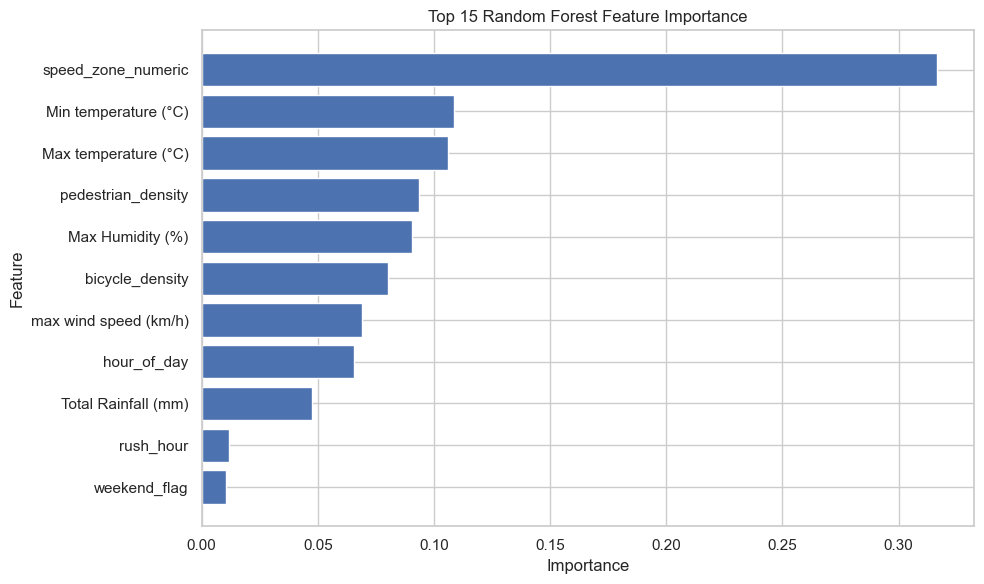

In [43]:
# Clean and plot Random Forest feature importance

feature_importance_clean = feature_importance.copy()

# Clean column names
feature_importance_clean.columns = (
    feature_importance_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Columns found:")
print(feature_importance_clean.columns.tolist())

# Try to detect feature and importance columns
feature_col = None
importance_col = None

possible_feature_cols = ["feature", "features", "variable", "column"]
possible_importance_cols = ["importance", "feature_importance", "score", "value"]

for col in possible_feature_cols:
    if col in feature_importance_clean.columns:
        feature_col = col
        break

for col in possible_importance_cols:
    if col in feature_importance_clean.columns:
        importance_col = col
        break

# Fallback if names are different
if feature_col is None:
    feature_col = feature_importance_clean.columns[0]

if importance_col is None:
    importance_col = feature_importance_clean.columns[1]

feature_importance_clean[importance_col] = pd.to_numeric(
    feature_importance_clean[importance_col],
    errors="coerce"
)

# Select top 15 features
top_features = (
    feature_importance_clean
    .dropna(subset=[importance_col])
    .sort_values(importance_col, ascending=False)
    .head(15)
)

display(top_features[[feature_col, importance_col]])

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(
    top_features[feature_col][::-1],
    top_features[importance_col][::-1]
)
plt.title("Top 15 Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Feature Importance Observations

The Random Forest feature importance chart shows that **speed_zone_numeric** is the most influential feature in the model by a clear margin. This suggests that speed zone information played the strongest role in predicting crash severity outcomes.

Weather-related variables also appear important. **Minimum temperature, maximum temperature, maximum humidity, maximum wind speed, and total rainfall** are all included among the top features. This indicates that environmental conditions contributed meaningful information to the model.

Mobility-related features are also important. Both **pedestrian_density** and **bicycle_density** appear in the top feature list, showing that active transport movement around crash areas helped the model understand crash severity patterns.

Time-related variables such as **hour_of_day**, **rush_hour**, and **weekend_flag** also contributed to prediction. This supports the earlier dashboard findings that crash patterns vary by time of day and travel behaviour.

From a stakeholder perspective, the most useful insight is that crash severity is influenced by a combination of **speed environment, weather conditions, mobility exposure, and time-based travel patterns**. These features can help local government teams focus further investigation on high-risk speed zones, busy pedestrian/cyclist areas, and periods affected by weather or peak travel activity.

However, feature importance should not be interpreted as direct causation. It shows which variables helped the model make predictions, but further road safety analysis and local context are needed before turning these findings into policy or infrastructure decisions.

## 13. Final Model Summary

### Final Selected Model

**Selected model:** Random Forest

**Reason for selection:** Random Forest was selected because it achieved the strongest overall performance among the tested models. It had the highest accuracy, macro F1-score, and weighted F1-score compared with Logistic Regression, Decision Tree, and XGBoost.

**Main strength:** The main strength of the Random Forest model is that it provides the best overall balance across the available performance metrics. It also performs better than XGBoost for the Serious injury accident class based on F1-score.

**Main limitation:** The model still struggles with the Fatal accident class. Fatal crashes are rare in the dataset, so precision and F1-score for this class remain low. This means the model should be treated as a decision-support tool rather than an operational prediction system for fatal crash detection.

### Final Model Summary Observations

The final selected model for this project is **Random Forest**.

Random Forest was selected because it achieved the strongest overall performance across the model comparison results. It had the highest accuracy, macro F1-score, and weighted F1-score among the tested models.

The model also provided useful feature importance outputs, which makes it more interpretable for the final dashboard. The feature importance chart showed that speed zone, weather variables, pedestrian density, bicycle density, and time-based variables contributed to the model’s predictions.

However, the model should be interpreted carefully. The class-wise results showed that Random Forest performs well for the **Other injury accident** class and reasonably better than XGBoost for **Serious injury accident**, but it still struggles with **Fatal accident** prediction.

This is mainly because fatal crashes are rare compared with other crash categories. As a result, the model has low precision and low F1-score for fatal crashes.

Overall, Random Forest is the most suitable model for the final project summary because it provides the best overall predictive performance and useful interpretability. However, it should be used as a **risk insight and decision-support model**, not as a final operational system for predicting fatal crashes.

## 14. Key Findings for Local Government Stakeholders

The dashboard should be interpreted as a **decision-support tool**, not a replacement for professional road safety assessment, engineering judgement, or local government policy review.

Key messages for a non-technical audience:

- Crash records are not evenly distributed across time, conditions, and road environments.
- The highest crash activity appears during daytime and commuting periods, especially around the afternoon peak.
- Most crashes in the dataset are injury-related, while fatal crashes are much less frequent but remain the most critical from a safety perspective.
- Crash records are highly concentrated in common urban speed zones, especially **50–60 km/h**, where there may be more intersections, pedestrians, cyclists, and local traffic movement.
- Higher-speed zones such as **80–100 km/h** should still be reviewed carefully because crashes in these environments may lead to more severe outcomes.
- Rainfall-related analysis shows most crashes occurred during no-rain conditions, but this should be interpreted with exposure in mind because dry conditions occur more often.
- Mobility features such as **pedestrian_density** and **bicycle_density** were important in the model, suggesting that active transport movement provides useful context for crash risk.
- The **Random Forest** model performed best overall, but fatal crash prediction remains difficult because fatal accidents are rare in the dataset.
- Model outputs should be used to prioritise further investigation, not to make automatic safety decisions.

## 15. Recommended Actions

Based on the dashboard outcomes, the following actions can be considered:

1. **Review afternoon peak-risk periods**, especially around school pick-up, commuting hours, busy intersections, and high pedestrian/cyclist activity areas.

2. **Prioritise 50–60 km/h urban corridors** for safety review, as these speed zones contain the largest number of crash records and may involve mixed road users.

3. **Review higher-speed roads such as 80–100 km/h zones** for serious and fatal crash risk, focusing on road design, visibility, roadside hazards, speed management, and intersection treatments.

4. **Use pedestrian and bicycle density insights** to identify locations where vulnerable road users may need better protection, such as improved crossings, cycle lanes, traffic calming, and separation from vehicles.

5. **Interpret rainfall and weather findings together with exposure data**, because raw crash counts do not show risk unless compared with how often those conditions occur and how much traffic is present.

6. **Use the Random Forest model as a decision-support tool** to highlight risk patterns, while continuing to validate findings with local road safety experts and engineering judgement.

7. **Improve future modelling by adding richer location and exposure data**, such as traffic volume, road type, intersection type, lighting, road surface condition, and more detailed geographic features.

8. **Develop an interactive Power BI or web dashboard** if stakeholders need ongoing reporting, filtering by time, severity, speed zone, weather, mobility, and model risk indicators.

## 16. Limitations

This dashboard and modelling summary should be interpreted with the following limitations:

- The crash, weather, and mobility datasets may not align perfectly by time, location, or level of detail. This can affect how accurately external conditions are linked to individual crash records.

- Some features, such as rainfall, pedestrian density, and bicycle density, provide useful context but do not prove direct causation.

- The dataset is imbalanced. Fatal accidents and non-injury accidents have far fewer records than injury-related crashes, which makes these classes harder for the model to predict accurately.

- The Random Forest model performed best overall, but class-wise results show that fatal crash prediction remains weak due to low precision and low F1-score.

- Crash counts should not be interpreted as risk on their own. They should be compared with exposure factors such as traffic volume, pedestrian activity, cyclist activity, and how often weather conditions occur.

- The model identifies historical risk patterns, not guaranteed future crash events.

- Further validation with road safety experts, local government stakeholders, and engineering judgement is recommended before using the outputs for operational decisions.

## 17. Conclusion

This dashboard summary notebook brings together the key outcomes of the **Traffic Accident Risk Prediction (TARP)** project.

The final dataset contains more than **151,000 crash records** and combines crash severity, time-based features, weather information, speed zone details, and mobility-related indicators such as pedestrian and bicycle density.

The analysis showed that crash patterns vary by severity, time of day, speed zone, rainfall, mobility density, and other environmental conditions. The dashboard also highlighted that most crashes are injury-related, while fatal crashes are rare but critical from a road safety perspective.

The modelling results showed that **Random Forest** was the strongest overall model among the tested approaches. It achieved the best overall balance across accuracy, macro F1-score, and weighted F1-score, and provided useful feature importance insights. However, fatal crash prediction remains challenging due to class imbalance.

Overall, this notebook provides a clear handover summary for stakeholders. It can support local government teams in identifying important crash risk patterns, prioritising further investigation, and planning future road safety improvements. The results should be used as a **decision-support tool** alongside local knowledge, engineering assessment, and policy judgement.